# Sandeep Parupalli  
University of the Cumberlands  
2026 Spring - Advanced Big Data and Data Mining (MSCS-634-B01)  
Satish Penmatsa (Instructor)  

# Project Deliverable 2: Regression Modeling and Performance Evaluation

This notebook focuses only on the regression phase of the project. It uses the Online Retail dataset to predict customer spending behavior after cleaning the data, building customer-level features, and comparing multiple regression models.

**GitHub Repository:** https://github.com/Sandeep271/Project

## Deliverable goal

In this deliverable, I predict **log-transformed total customer spending** from customer purchase behavior and pricing patterns. The work in this notebook is organized to match the project requirements:

- focused data cleaning for regression modeling
- feature engineering to improve predictive performance
- comparison of multiple regression models
- evaluation using **R-squared, MSE, RMSE, and MAE**
- cross-validation to assess generalization
- short interpretation of what the results mean


In [1]:
# Import the libraries needed for data preparation, regression modeling, and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import display

# Load the Online Retail dataset from the local project folder.
df = pd.read_excel("Online Retail.xlsx", sheet_name="Online Retail")

# Display the first few rows so the structure of the raw data is easy to inspect.
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Dataset summary

The dataset contains transaction-level retail records. Each row represents one invoice line and includes information such as invoice number, stock code, product description, quantity, invoice date, unit price, customer ID, and country.

For this deliverable, the raw transaction data is cleaned and then aggregated to the **customer level**. That makes the regression task more meaningful because the target becomes customer spending rather than a single invoice line.

In [2]:
# Check the size of the original dataset and list the available columns.
print("Original shape:", df.shape)
print("\nColumns:")
print(df.columns)

Original shape: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [3]:
# Remove duplicate rows so repeated records do not distort the model.
df_clean = df.drop_duplicates()

# Remove rows with missing Description or CustomerID.
# CustomerID is required because the regression task is built at the customer level.
df_clean = df_clean.dropna(subset=["Description", "CustomerID"])

# Keep only rows with positive quantity and positive unit price.
# Negative or zero values would not make sense for the spending target in this deliverable.
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].copy()

# Create transaction-level sales and a month feature for later aggregation.
df_clean["TotalSales"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["Month"] = df_clean["InvoiceDate"].dt.month

print("Cleaned shape:", df_clean.shape)

Cleaned shape: (392692, 10)


## Customer-level modeling table

The original file is at the transaction level, but regression in this deliverable is based on customer behavior. I aggregate the cleaned data so each row represents one customer and summarizes how that customer purchased over time.

In [4]:
# Aggregate the cleaned transaction data to the customer level.
customer_df = df_clean.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "UnitPrice": "mean",
    "TotalSales": "sum",
    "Month": "nunique"
}).reset_index()

# Rename the columns to make the modeling table easier to read.
customer_df.columns = [
    "CustomerID",
    "NumTransactions",
    "TotalQuantity",
    "AvgUnitPrice",
    "TotalSpent",
    "ActiveMonths"
]

# Display the first few rows of the customer-level table.
customer_df.head()

,CustomerID,NumTransactions,TotalQuantity,AvgUnitPrice,TotalSpent,ActiveMonths,AvgQuantityPerTransaction,QuantityPriceInteraction,LogTotalSpent
0,12346.0,1,74215,1.040000,77183.60,1,74215.000000,77183.600000,11.253955
1,12347.0,7,2458,2.644011,4310.00,6,351.142857,6498.979011,8.368925
2,12348.0,4,2341,5.764839,1797.24,4,585.250000,13495.487419,7.494564
3,12349.0,1,631,8.289041,1757.55,1,631.000000,5230.384932,7.472245
4,12350.0,1,197,3.841176,334.40,1,197.000000,756.711765,5.815324


## Feature engineering

To improve model performance, I create a few additional variables:

- **AvgQuantityPerTransaction** helps capture average purchase intensity.
- **QuantityPriceInteraction** captures the combined effect of buying more items at a given average price.
- **LogTotalSpent** is used as the target because raw customer spending is strongly right-skewed.

These features are intended to give the models a clearer view of customer behavior.

In [5]:
# Create engineered features for the regression task.
customer_df["AvgQuantityPerTransaction"] = (
    customer_df["TotalQuantity"] / customer_df["NumTransactions"]
)

customer_df["QuantityPriceInteraction"] = (
    customer_df["TotalQuantity"] * customer_df["AvgUnitPrice"]
)

# Log-transform the target to reduce skewness and stabilize the regression problem.
customer_df["LogTotalSpent"] = np.log1p(customer_df["TotalSpent"])

# Display the first few rows after feature engineering.
customer_df.head()

,CustomerID,NumTransactions,TotalQuantity,AvgUnitPrice,TotalSpent,ActiveMonths,AvgQuantityPerTransaction,QuantityPriceInteraction,LogTotalSpent
0,12346.0,1,74215,1.040000,77183.60,1,74215.000000,77183.600000,11.253955
1,12347.0,7,2458,2.644011,4310.00,6,351.142857,6498.979011,8.368925
2,12348.0,4,2341,5.764839,1797.24,4,585.250000,13495.487419,7.494564
3,12349.0,1,631,8.289041,1757.55,1,631.000000,5230.384932,7.472245
4,12350.0,1,197,3.841176,334.40,1,197.000000,756.711765,5.815324


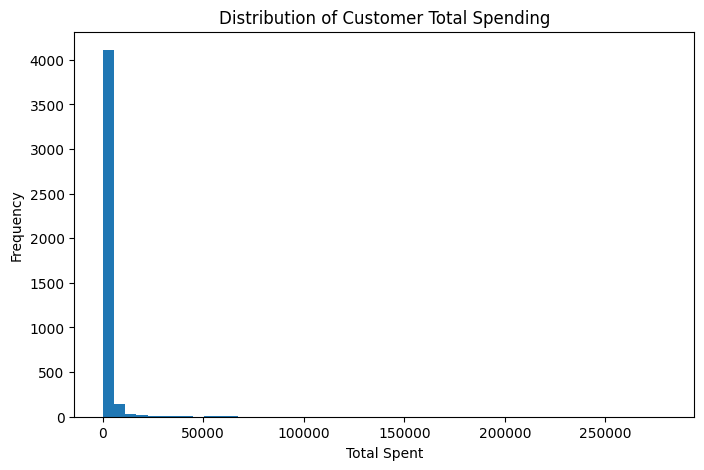

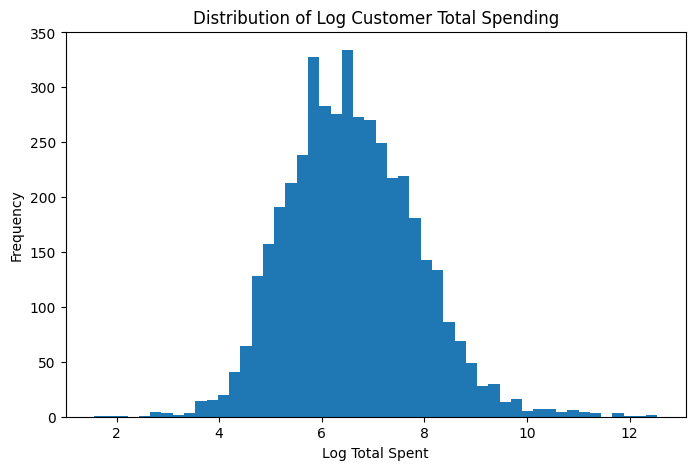

In [6]:
# Compare the original spending target and the log-transformed target visually.
plt.figure(figsize=(8, 5))
plt.hist(customer_df["TotalSpent"], bins=50)
plt.title("Distribution of Customer Total Spending")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(customer_df["LogTotalSpent"], bins=50)
plt.title("Distribution of Log Customer Total Spending")
plt.xlabel("Log Total Spent")
plt.ylabel("Frequency")
plt.show()

## Baseline feature set vs engineered feature set

Before comparing different regression models, I first check whether feature engineering helps. I compare a baseline linear regression model against a second linear regression model that uses the engineered features.

In [7]:
# Define the original feature set and the expanded engineered feature set.
baseline_features = [
    "NumTransactions",
    "TotalQuantity",
    "AvgUnitPrice",
    "ActiveMonths"
]

engineered_features = baseline_features + [
    "AvgQuantityPerTransaction",
    "QuantityPriceInteraction"
]

# Train and evaluate a baseline linear regression model.
X_base = customer_df[baseline_features]
y = customer_df["LogTotalSpent"]

X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

base_model = LinearRegression()
base_model.fit(X_base_train, y_base_train)
base_pred = base_model.predict(X_base_test)

# Train and evaluate a second linear regression model using engineered features.
X_engineered = customer_df[engineered_features]

X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42
)

eng_model = LinearRegression()
eng_model.fit(X_eng_train, y_eng_train)
eng_pred = eng_model.predict(X_eng_test)

# Store the comparison results in a small table.
feature_comparison_df = pd.DataFrame({
    "Feature Set": ["Baseline", "Engineered"],
    "R2": [
        r2_score(y_base_test, base_pred),
        r2_score(y_eng_test, eng_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_base_test, base_pred)),
        np.sqrt(mean_squared_error(y_eng_test, eng_pred))
    ],
    "MAE": [
        mean_absolute_error(y_base_test, base_pred),
        mean_absolute_error(y_eng_test, eng_pred)
    ]
})

display(feature_comparison_df)

,Feature Set,R2,RMSE,MAE
0,Baseline,0.633834,0.766523,0.582728
1,Engineered,0.636985,0.763217,0.582322


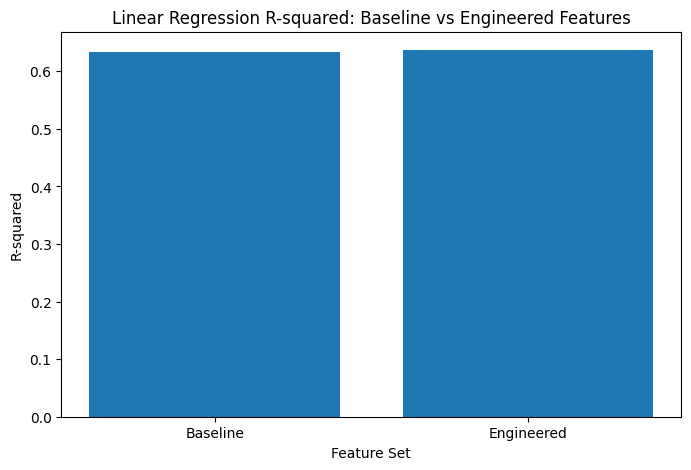

In [8]:
# Visualize how feature engineering changes R-squared.
plt.figure(figsize=(8, 5))
plt.bar(feature_comparison_df["Feature Set"], feature_comparison_df["R2"])
plt.title("Linear Regression R-squared: Baseline vs Engineered Features")
plt.xlabel("Feature Set")
plt.ylabel("R-squared")
plt.show()

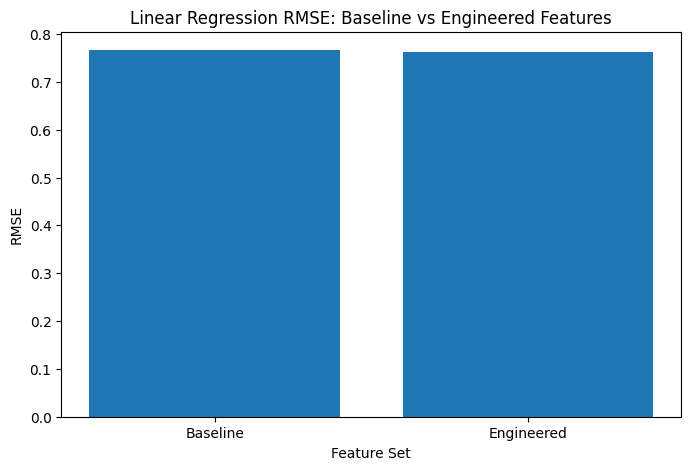

In [9]:
# Visualize how feature engineering changes RMSE.
plt.figure(figsize=(8, 5))
plt.bar(feature_comparison_df["Feature Set"], feature_comparison_df["RMSE"])
plt.title("Linear Regression RMSE: Baseline vs Engineered Features")
plt.xlabel("Feature Set")
plt.ylabel("RMSE")
plt.show()

The engineered feature set gives a small but real improvement, so I use it for the final regression model comparison.

In [10]:
# Use the engineered feature set for the final regression comparison.
X = customer_df[engineered_features]
y = customer_df["LogTotalSpent"]

# Split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3470, 6)
X_test shape: (868, 6)
y_train shape: (3470,)
y_test shape: (868,)


## Regression models

I compare three models:

1. **Linear Regression**
2. **Ridge Regression**
3. **Lasso Regression**

Linear Regression gives a plain baseline, while Ridge and Lasso test whether regularization improves results.

In [11]:
# Build and evaluate three regression models on the same train/test split.
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000)
}

results = []

for model_name, model in models.items():
    # Train the model.
    model.fit(X_train, y_train)

    # Generate predictions on the test set.
    y_pred = model.predict(X_test)

    # Store multiple evaluation metrics for comparison.
    results.append({
        "Model": model_name,
        "R2": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,R2,MSE,RMSE,MAE
0,Linear Regression,0.636985,0.582501,0.763217,0.582322
1,Ridge Regression,0.636987,0.582498,0.763215,0.582319
2,Lasso Regression,0.637000,0.582476,0.763201,0.582299


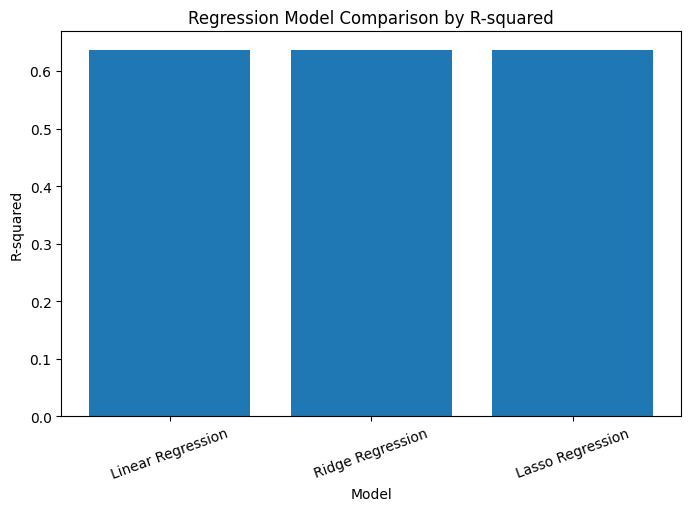

In [12]:
# Visualize model performance using R-squared.
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Regression Model Comparison by R-squared")
plt.xlabel("Model")
plt.ylabel("R-squared")
plt.xticks(rotation=20)
plt.show()

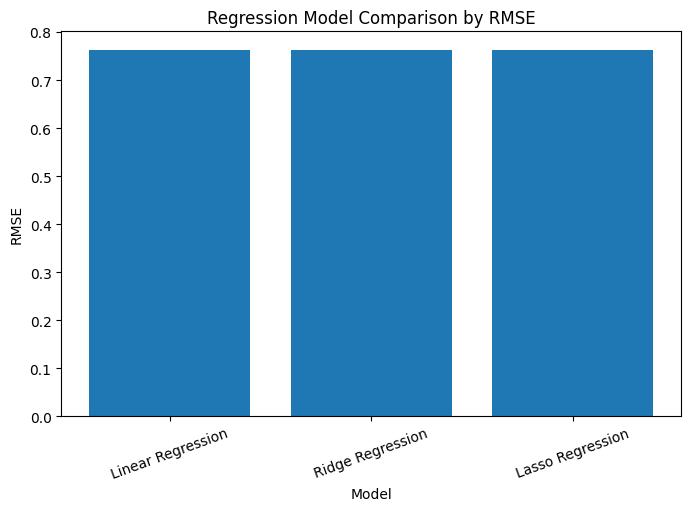

In [13]:
# Visualize model performance using RMSE.
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Regression Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

## Cross-validation

A single train/test split is useful, but it can still depend on one random split. To check how well the models generalize, I use **5-fold cross-validation** with shuffled folds and compare the mean **R-squared** values.

In [14]:
# Use 5-fold cross-validation to assess generalization.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for model_name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

    cv_results.append({
        "Model": model_name,
        "CV Mean R2": cv_scores.mean(),
        "CV Std R2": cv_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

,Model,CV Mean R2,CV Std R2
0,Linear Regression,0.570951,0.100245
1,Ridge Regression,0.570950,0.100247
2,Lasso Regression,0.570977,0.100245


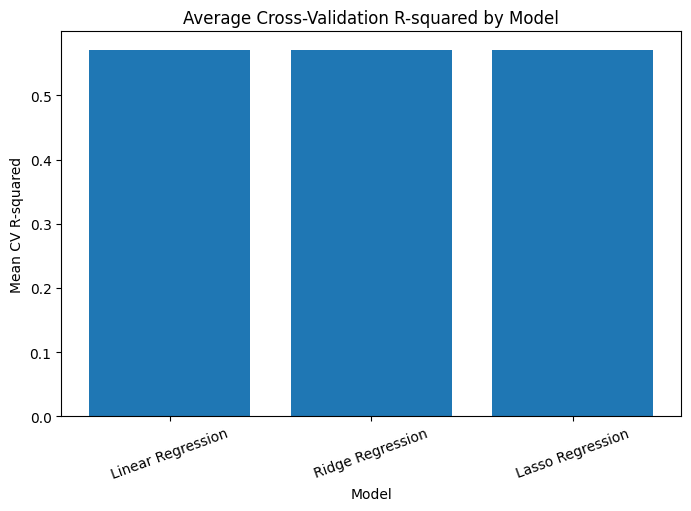

In [15]:
# Plot the average cross-validation R-squared values.
plt.figure(figsize=(8, 5))
plt.bar(cv_results_df["Model"], cv_results_df["CV Mean R2"])
plt.title("Average Cross-Validation R-squared by Model")
plt.xlabel("Model")
plt.ylabel("Mean CV R-squared")
plt.xticks(rotation=20)
plt.show()

## Best model prediction plot

The next chart compares actual and predicted values for the best model from the test-set comparison. This helps show whether the model follows the overall pattern of the data.

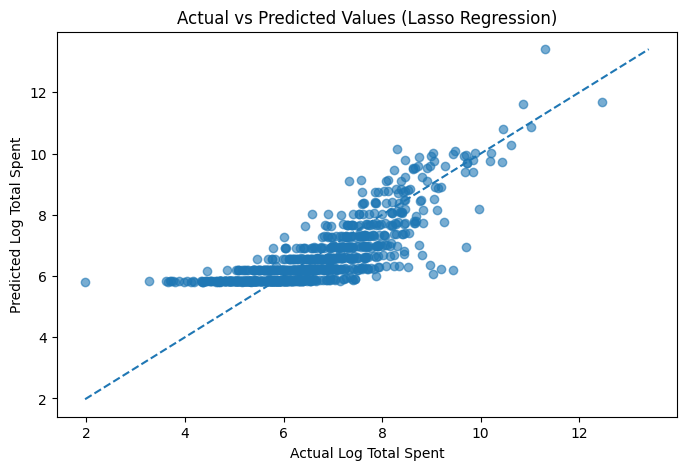

In [16]:
# Identify the best model using high R-squared and low RMSE.
best_model_name = results_df.sort_values(by=["R2", "RMSE"], ascending=[False, True]).iloc[0]["Model"]
best_model = models[best_model_name]

# Refit the best model and create predictions for a scatter plot.
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.plot(
    [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())],
    [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())],
    linestyle="--"
)
plt.title(f"Actual vs Predicted Values ({best_model_name})")
plt.xlabel("Actual Log Total Spent")
plt.ylabel("Predicted Log Total Spent")
plt.show()

## Final interpretation

The regression models perform very similarly on this dataset. The engineered features improve the linear regression baseline a little, which suggests that purchase intensity and the interaction between quantity and price add useful information.

Among the final models, **Lasso Regression** performs best on the test set, but the margin is extremely small. That means the dataset appears fairly stable and close to linear, so regularization does not change performance very much.

The cross-validation results are lower than the single test-set scores, which is expected, but they remain reasonably consistent across folds. Overall, the models generalize moderately well and provide a solid basis for understanding customer spending behavior.

In [17]:
# Display the final summary tables one more time for quick review.
print("Feature engineering comparison:")
display(feature_comparison_df)

print("\nRegression model evaluation:")
display(results_df)

print("\nCross-validation results:")
display(cv_results_df)

Feature engineering comparison:


,Feature Set,R2,RMSE,MAE
0,Baseline,0.633834,0.766523,0.582728
1,Engineered,0.636985,0.763217,0.582322



Regression model evaluation:


,Model,R2,MSE,RMSE,MAE
0,Linear Regression,0.636985,0.582501,0.763217,0.582322
1,Ridge Regression,0.636987,0.582498,0.763215,0.582319
2,Lasso Regression,0.637000,0.582476,0.763201,0.582299



Cross-validation results:


,Model,CV Mean R2,CV Std R2
0,Linear Regression,0.570951,0.100245
1,Ridge Regression,0.570950,0.100247
2,Lasso Regression,0.570977,0.100245
